# Parameter drift and convergence
We want to check how the parameters of the controller and drift make the system converge or diverge: $\eta$, $\gamma$ and quantization.

In [6]:
# Import enabol after adding it to the path
import enabol

# Numpy
import numpy as np

[INFO] - ENABOL imported successfully! Version: 0.1.0, URL: https://manuelblancovalentin.github.io/ENABOL/


### Global config

In [7]:
N = 1000
SEED = 42
MAX_STEPS = 1000
TARGET_LOSS = None
PATIENCE = 0
BLOWUP_LOSS = 1e2
controller_enabled = True
controller_name = [None, "gt-order-0", "gt-order-1", "gt-order-2"][2 if controller_enabled else 0]

# Gamma space 
ETAS = np.logspace(-2, 0.3, 41)         # 0.01 to about 2
GAMMAS = np.geomspace(1.0, 4.0, 41)    # 1 to 16
CHI = 1.0
PRECISIONS = [[16, 6]] # [[WL, IWL]]

### Dataset

In [10]:
dataset = enabol.AffineDataset(num_samples=N, use_bias=False, seed=SEED)
X, Y = dataset.get()
print(dataset)

AffineDataset(
 [Input] X: 
    Shape: (1000, 4)
    Dtype: DataType.D2_FLOAT
    X <- Uniform(-1, 1)
 [Output] Y: 
    Shape: (1000, 2)
    Dtype: DataType.D2_FLOAT
    Y <- X @ A.T + b
 ---------
  A = [[ 1.25 -0.75  0.5   0.2 ]
       [-0.4   0.9   1.1  -0.6 ]]
  b = [0. 0.]
----------
Analytic Hessian:
  Lambda max: 1.0822
  Eta max: 1.8481
)


### Model

In [5]:
model = enabol.LinearBlockModel(
    dataset=dataset,
    num_hidden=[dataset.A.shape[0]],
    activation=None,
    use_batchnorm=False,
    use_bias=False,
    seed=SEED,
)

model.summary()

Model: "LinearBlockModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ model_input (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense0 (Dense)                  │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Utility to reset the model weights to their initial state (we want every point to start from the same initial condition)
initial_weights = model.model.get_weights()

def reset_model(model):
    model.model.set_weights(initial_weights)

### Precisions

In [7]:
from enabol import dtypes, PrecisionDict

def make_precision_dict(BASE_WL, BASE_IWL, QMODE="AP_RND", OMODE="AP_SAT"):
    wide_weight = dtypes.ap_fixed(WL=BASE_WL, IWL=BASE_IWL, QMODE=QMODE, OMODE=OMODE)
    wide_activation = dtypes.ap_fixed(WL=BASE_WL, IWL=BASE_IWL+2, QMODE=QMODE, OMODE=OMODE)
    wide_gradient = dtypes.ap_fixed(WL=BASE_WL+4, IWL=BASE_IWL+2, QMODE=QMODE, OMODE=OMODE)
    wide_update = dtypes.ap_fixed(WL=BASE_WL+4, IWL=BASE_IWL, QMODE=QMODE, OMODE=OMODE)
    wide_accumulator = dtypes.ap_fixed(WL=BASE_WL+12, IWL=BASE_IWL+8, QMODE=QMODE, OMODE=OMODE)
    wide_loss = dtypes.ap_fixed(WL=2*BASE_WL, IWL=BASE_IWL+10, QMODE=QMODE, OMODE=OMODE)
    return PrecisionDict({
                "input": {"value": wide_activation},
                "dense0": {
                    "weight": wide_weight,
                    "activation": wide_activation,
                    "gradient": wide_gradient,
                    "update": wide_update,
                    "accumulator": wide_accumulator,
                },
                "loss": {"value": wide_loss},
            })


### Metrics

In [8]:
from enabol import MetricsConfig

warmup_metrics = MetricsConfig(
    profiles=("core", "geometry", "stability", "teacher", "quantization", "controller_bounds"),
    reference_A=dataset.reference_weight_matrix,
)
print(warmup_metrics)



╔═════════════════════════════════════════════════════════════════════════════════════════════════════╗
║ MetricsConfig                                                                                       ║
╟───────────────────────────────┬─────────────────────────────────────────────────────────────────────╢
║ Setting                       │ value                                                               ║
╟───────────────────────────────┼─────────────────────────────────────────────────────────────────────╢
║ profiles                      │ core, geometry, stability, teacher, quantization, controller_bounds ║
║ fields                        │ 36                                                                  ║
║ compute_analytic_hessian      │ ● True                                                              ║
║ requires_hessian              │ ● True                                                              ║
║ requires_teacher              │ ● True                        

### Utils

In [9]:
def safe_max(h, key):
    if key not in h:
        return np.nan
    x = np.asarray(h[key], dtype=float)
    if x.size == 0:
        return np.nan
    return float(np.nanmax(x))


def safe_min(h, key):
    if key not in h:
        return np.nan
    x = np.asarray(h[key], dtype=float)
    if x.size == 0:
        return np.nan
    return float(np.nanmin(x))


def safe_final(h, key):
    if key not in h:
        return np.nan
    x = np.asarray(h[key], dtype=float)
    if x.size == 0:
        return np.nan
    return float(x[-1])

def summarize_run(h, eta, gamma, precision_dict, controller_name):
    loss = h["loss"]
    finite = np.all(np.isfinite(loss))
    diverged = (not finite) or bool(np.any(h["diverged"] > 0)) or np.nanmax(loss) > BLOWUP_LOSS

    converged = False
    converged_step = np.nan
    if not diverged:
        if TARGET_LOSS is not None:
            below = loss < TARGET_LOSS
            for idx in range(len(loss) - PATIENCE):
                if np.all(below[idx:idx + PATIENCE]):
                    converged = True
                    converged_step = idx
                    break
        else:
            converged = True
            converged_step = len(loss)

    return {
        "eta": eta,
        "gamma": gamma,
        "controller": controller_name or "none",
        "precision": str(precision_dict["dense0"]["weight"]),
        "diverged": diverged,
        "converged": converged,
        "converged_step": converged_step,
        "final_loss": float(loss[-1]),
        "log_final_loss": float(np.log10(loss[-1] + 1e-12)) if not diverged else np.nan,
        "final_alpha": float(h["alpha"][-1]),
        "min_alpha": float(np.nanmin(h["alpha"])),
        "min_update_cosine": float(np.nanmin(h["update_cosine"])),
        "max_grad_sat": float(np.nanmax(h["gradient_saturation_fraction_max"])),
        "max_curvature_proxy": safe_max(h, "curvature_proxy"),
        "max_curvature_for_control": safe_max(h, "curvature_for_control"),
        "max_hessian_lambda": safe_max(h, "hessian_lambda_max"),
        "max_hessian_spectral_norm": safe_max(h, "hessian_spectral_norm"),
        "max_margin_lambda_raw": safe_max(h, "stability_margin_lambda_raw"),
        "max_margin_lambda_ctrl": safe_max(h, "stability_margin_lambda_ctrl"),
        "max_margin_norm_raw": safe_max(h, "stability_margin_norm_raw"),
        "max_margin_norm_ctrl": safe_max(h, "stability_margin_norm_ctrl"),
        "max_spectral_radius_raw": safe_max(h, "spectral_radius_raw"),
        "max_spectral_radius_ctrl": safe_max(h, "spectral_radius_ctrl"),
        "final_margin_lambda_raw": safe_final(h, "stability_margin_lambda_raw"),
        "final_margin_lambda_ctrl": safe_final(h, "stability_margin_lambda_ctrl"),
        "min_controller_feasible": safe_min(h, "controller_feasible"),
        "min_alpha_min_bound": safe_min(h, "alpha_min_bound"),
        "max_alpha_min_bound": safe_max(h, "alpha_min_bound"),
        "min_alpha_max_bound": safe_min(h, "alpha_max_bound"),
        "max_alpha_max_bound": safe_max(h, "alpha_max_bound"),
    }

### For loop

In [11]:
results = []

total_runs = len(PRECISIONS) * len(ETAS) * len(GAMMAS)
for i, (WL, IWL) in enumerate(PRECISIONS):
    precision_dict = make_precision_dict(WL, IWL)
    
    for j, GAMMA in enumerate(GAMMAS):

        # Make drifted dataset
        Xd = GAMMA * X

        # Metrics
        drift_metrics = MetricsConfig(
            profiles=("core", "geometry", "stability", "teacher", "quantization", "controller_bounds"),
            reference_A=dataset.reference_weight_matrix / GAMMA,
        )


        for k, ETA in enumerate(ETAS):
            # Print
            iteration = i * len(GAMMAS) * len(ETAS) + j * len(ETAS) + k
            print(f"[{(iteration+1)/total_runs:.2%}] Running with ETA={ETA}, GAMMA={GAMMA}, {precision_dict['dense0']['weight']}")

            # Reset model weights
            reset_model(model)
            
            # We need a new controller for every run, since it has states (not for 0th or None, but it's good practice anyways)
            controller = enabol.Controller.from_str(controller_name, chi=CHI)

            # Train
            h_nom = model.train_instrumented(
                Xd,
                Y,
                epochs=MAX_STEPS,
                stop_loss=None,       # auto means lower bound according to quantization.
                diverge_loss=BLOWUP_LOSS,   # auto means upper bound according to quantization.
                stop_patience=1, 
                stop_min_steps=0,
                batch_size=len(Xd),
                learning_rate=ETA,
                controller=controller,
                metrics=drift_metrics,
                precision_dict=precision_dict,
                verbose = 'progressbar'
            )

            # Append result
            results.append(summarize_run(h_nom, ETA, GAMMA, precision_dict, controller_name))



[0.06%] Running with ETA=0.01, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=9.3658e-02 α=1.000
[0.12%] Running with ETA=0.011415633046188459, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=7.5516e-02 α=1.000
[0.18%] Running with ETA=0.013031667784522994, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=6.0684e-02 α=1.000
[0.24%] Running with ETA=0.014876473740795015, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=4.8218e-02 α=1.000
[0.30%] Running with ETA=0.016982436524617443, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=3.7064e-02 α=1.000
[0.36%] Running with ETA=0.019386526359522076, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████████████████] 1000/1000 loss=2.8366e-02 α=1.000
[0.42%] Running with ETA=0.022130947096056376, GAMMA=1.0, ap_fixed<16,6,AP_RND,AP_SAT>
[████████████████

In [12]:
# h_nom.plot_results(title="Warmup History")
import pandas as pd
df = pd.DataFrame(results)
FILE = f"../results/parameter_sweep5_controller_{controller_name}.csv"
df.to_csv(FILE, index=False)

In [130]:

# Now we need to form the (eta,gamma) grid that's the same for all metrics.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.ndimage import distance_transform_edt

def deepest_nan_point(A, etas, gammas):
    A = np.asarray(A)
    etas = np.asarray(etas)
    gammas = np.asarray(gammas)

    mask = np.isnan(A)

    if not np.any(mask):
        return None

    # Distance, in pixel units, from every NaN cell to nearest non-NaN cell
    dist = distance_transform_edt(mask)

    i, j = np.unravel_index(np.argmax(dist), dist.shape)

    eta_rep = etas[i]
    gamma_rep = gammas[j]

    return gamma_rep, eta_rep

def _parse_float(value: str) -> float:
    if value == "" or value is None:
        return np.nan
    return float(value)

def get_mesh(df: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    etas = np.array(sorted(df['eta'].unique()), dtype=float)
    gammas = np.array(sorted(df['gamma'].unique()), dtype=float)
    return etas, gammas

def pivot_grid(
    df: pd.DataFrame,
    etas: np.ndarray,
    gammas: np.ndarray,
    *,
    value: str,
    black_diverged: bool = True,
) -> np.ndarray:
    grid = np.full((len(etas), len(gammas)), np.nan, dtype=float)

    eta_index = {eta: i for i, eta in enumerate(etas)}
    gamma_index = {gamma: j for j, gamma in enumerate(gammas)}
    for _, row in df.iterrows():
        eta = float(row["eta"])
        gamma = float(row["gamma"])
        if black_diverged and row.get("diverged"):
            continue
        grid[eta_index[eta], gamma_index[gamma]] = _parse_float(row.get(value, ""))
    return grid


def geomspace_edges(x):
    x = np.asarray(x, dtype=float)

    if np.any(x <= 0):
        raise ValueError("Geometric edges require strictly positive coordinates.")

    if x.ndim != 1:
        raise ValueError("x must be 1D.")

    if len(x) < 2:
        raise ValueError("Need at least two points to compute edges.")

    edges = np.empty(len(x) + 1)

    # Interior edges: geometric midpoints
    edges[1:-1] = np.sqrt(x[:-1] * x[1:])

    # Boundary edges: extrapolate using the same geometric ratio
    r0 = x[1] / x[0]
    r1 = x[-1] / x[-2]

    edges[0] = x[0] / np.sqrt(r0)
    edges[-1] = x[-1] * np.sqrt(r1)

    return edges

def nan_centroid_physical_geomgrid(A, etas, gammas):
    A = np.asarray(A)
    etas = np.asarray(etas, dtype=float)
    gammas = np.asarray(gammas, dtype=float)

    mask = np.isnan(A)

    if not np.any(mask):
        return None

    gamma_edges = geomspace_edges(gammas)
    eta_edges = geomspace_edges(etas)

    dgamma = np.diff(gamma_edges)
    deta = np.diff(eta_edges)

    GAMMA, ETA = np.meshgrid(gammas, etas)
    DGAMMA, DETA = np.meshgrid(dgamma, deta)

    weights = DGAMMA * DETA

    W = weights[mask].sum()

    gamma_c = (GAMMA[mask] * weights[mask]).sum() / W
    eta_c = (ETA[mask] * weights[mask]).sum() / W

    return gamma_c, eta_c

def nan_centroid_logspace(A, etas, gammas):
    A = np.asarray(A)
    etas = np.asarray(etas, dtype=float)
    gammas = np.asarray(gammas, dtype=float)

    mask = np.isnan(A)

    if not np.any(mask):
        return None

    GAMMA, ETA = np.meshgrid(gammas, etas)

    log_gamma_c = np.log10(GAMMA[mask]).mean()
    log_eta_c = np.log10(ETA[mask]).mean()

    gamma_c = 10 ** log_gamma_c
    eta_c = 10 ** log_eta_c

    return gamma_c, eta_c

def nan_area_fraction_geomgrid(A, etas, gammas):
    A = np.asarray(A)
    etas = np.asarray(etas, dtype=float)
    gammas = np.asarray(gammas, dtype=float)

    if A.shape != (len(etas), len(gammas)):
        raise ValueError("A.shape must be (len(etas), len(gammas))")

    mask = np.isnan(A)

    gamma_edges = geomspace_edges(gammas)
    eta_edges = geomspace_edges(etas)

    dgamma = np.diff(gamma_edges)
    deta = np.diff(eta_edges)

    DGAMMA, DETA = np.meshgrid(dgamma, deta)

    cell_areas = DGAMMA * DETA

    divergent_area = cell_areas[mask].sum()
    total_area = cell_areas.sum()

    frac = divergent_area / total_area
    percent = 100 * frac

    return percent, divergent_area, total_area

def nan_area_fraction_loggrid(A):
    """
    Fraction of divergent cells in log-grid space.

    For geomspace/log-spaced sweeps, this corresponds to the visual area
    fraction on a log-log plot, and to the fraction of sampled configurations.
    """
    A = np.asarray(A)
    mask = np.isnan(A)

    return 100.0 * mask.mean()


def plot_phase(
    etas: np.ndarray,
    gammas: np.ndarray,
    *,
    grids: dict[str, np.ndarray],
    title: str | None = None,
    cmaps: dict[str, str] = {"log_final_loss": "viridis"},
    overlay_divergence: bool = True,
    chi: float | None = None,
    lambda_max: float | None = None,
    log: bool = True,
):

    NPLOTS = len(grids)
    NCOLS = np.sqrt(NPLOTS).round().astype(int)
    NROWS = np.ceil((NPLOTS / NCOLS)).astype(int)

    fig, axs = plt.subplots(nrows=NROWS, ncols=NCOLS, figsize=(7*NCOLS, 5*NROWS), 
                            sharex=True, sharey=True)

    axs = np.array(axs).flatten() if NPLOTS > 1 else np.array([axs])

    # Calculate the center of mass of the divergence area (where grid is NaN).
    gamma_edges = geomspace_edges(gammas)
    eta_edges = geomspace_edges(etas)
    gamma_c, eta_c = nan_centroid_logspace(grids["log_final_loss"], etas, gammas) # type: ignore
    div_percent = nan_area_fraction_loggrid(grids["log_final_loss"])

    if len(etas) >= 2 and len(gammas) >= 2:
        for ax, (value, grid) in zip(axs, grids.items()):
            # im = ax.imshow(
            #     np.ma.masked_invalid(grid),
            #     origin="lower",
            #     aspect="auto",
            #     interpolation="nearest",
            #     cmap=cmaps.get(value, "viridis"),
            #     extent=[gammas.min(), gammas.max(), etas.min(), etas.max()],
            # )
            im = ax.pcolormesh(
                gamma_edges,
                eta_edges,
                np.ma.masked_invalid(grid),
                shading="flat",
                cmap=cmaps.get(value, "viridis"),
            )

            #  Overlay the max stability margin line if chi and lambda_max are provided
            # which is: eta = (chi/lambda_max) * (1/gamma^2)
            if overlay_divergence and chi is not None and lambda_max is not None:
                stability_margin = (chi / lambda_max) * (1 / gammas**2)
                overlay_color_map = {"bwr": "black", "Spectral": "black", 
                                     "viridis": "red", "plasma": "white"}.get(cmaps.get(value, "viridis"), "red")
                ax.plot(gammas, stability_margin, color=overlay_color_map, linestyle="--")

                # Add text label at centroid saying "Divergence region"
                if np.isfinite(gamma_c) and np.isfinite(eta_c):
                    #ax.plot(gamma_c, eta_c, marker="X", color="red", markersize=10)
                    label = f"Divergence\n{div_percent:.1f}% area"
                    text_x = gamma_c
                    text_y = eta_c
                    if div_percent < 14:
                        text_x -= 0.4 * gamma_c
                        text_y -= 0.4 * eta_c
                        # Add an arrow pointing to the centroid
                        ax.annotate(
                            "",
                            xy=(gamma_c, eta_c),
                            xytext=(text_x, text_y),
                            arrowprops=dict(arrowstyle="->", color=overlay_color_map)
                        )
                    ax.text(
                        text_x,
                        text_y,
                        label,
                        color='black',
                        fontsize=10,
                        ha="left",
                        va="center",
                        bbox=dict(
                            facecolor="white",
                            alpha=0.8,
                            edgecolor='black',
                            boxstyle="round,pad=.5,rounding_size=0.2"
                        ),
                    )

            ax.set_xlabel("γ")
            ax.set_ylabel("η")
            if log:
                ax.set_yscale("log")
                ax.set_xscale("log")
            ax.set_title(title or value)
            fig.colorbar(im, ax=ax, label=value)
        # If there are any unused subplots, hide them
        for ax in axs[len(grids):]:
            ax.set_visible(False)
    else:
        raise ValueError("Need at least 2 unique values for eta and gamma to plot the phase diagram.")

    fig.tight_layout()


lambda_max: 1.0822006353226592, chi: 1.0


,eta,gamma,controller,precision,diverged,converged,converged_step,final_loss,log_final_loss,final_alpha,...,max_margin_norm_ctrl,max_spectral_radius_raw,max_spectral_radius_ctrl,final_margin_lambda_raw,final_margin_lambda_ctrl,min_controller_feasible,min_alpha_min_bound,max_alpha_min_bound,min_alpha_max_bound,max_alpha_max_bound
0,0.010000,1.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",False,True,1000.0,0.093658,-1.028453,1.0,...,0.010822,0.999232,0.999923,0.010822,0.010822,1.0,0.0,0.0,1.0,1.0
1,0.011416,1.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",False,True,1000.0,0.075516,-1.121962,1.0,...,0.012354,0.999123,0.999912,0.012354,0.012354,1.0,0.0,0.0,1.0,1.0
2,0.013032,1.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",False,True,1000.0,0.060684,-1.216924,1.0,...,0.014103,0.998999,0.999900,0.014103,0.014103,1.0,0.0,0.0,1.0,1.0
3,0.014876,1.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",False,True,1000.0,0.048218,-1.316793,1.0,...,0.016099,0.998857,0.999886,0.016099,0.016099,1.0,0.0,0.0,1.0,1.0
4,0.016982,1.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",False,True,1000.0,0.037064,-1.431052,1.0,...,0.018378,0.998696,0.999870,0.018378,0.018378,1.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1676,1.174898,4.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",True,False,NaN,103.369705,NaN,0.0,...,2.034360,19.343598,1.034360,20.343598,0.000000,1.0,0.0,0.0,1.0,1.0
1677,1.341220,4.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",True,False,NaN,164.751526,NaN,0.0,...,2.322350,22.223504,1.322350,23.223504,0.000000,1.0,0.0,0.0,1.0,1.0
1678,1.531087,4.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",True,False,NaN,181.918839,NaN,0.0,...,2.651110,25.511102,1.651110,26.511102,0.000000,1.0,0.0,0.0,1.0,1.0
1679,1.747833,4.0,gt-order-1,"ap_fixed<16,6,AP_RND,AP_SAT>",True,False,NaN,227.818695,NaN,0.0,...,3.026410,29.264100,2.026410,30.264100,0.000000,1.0,0.0,0.0,1.0,1.0


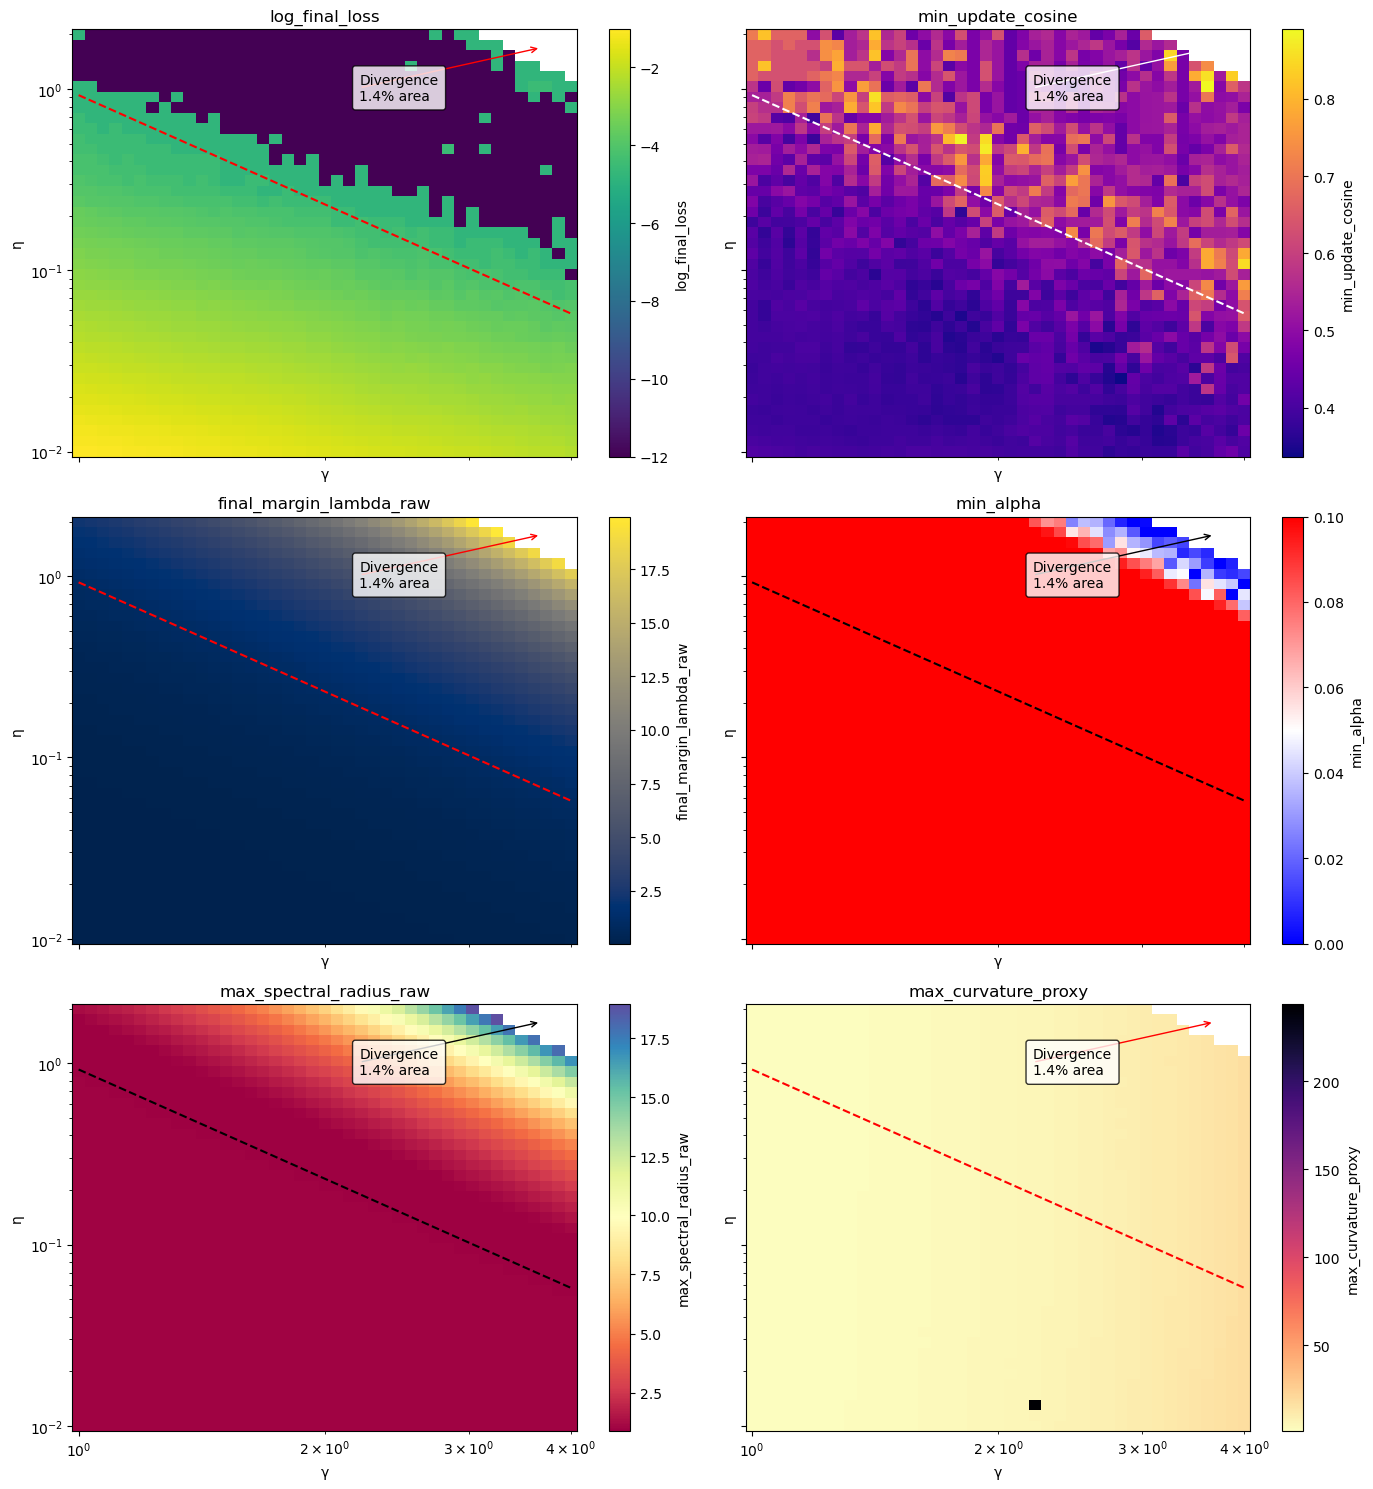

In [140]:
import pandas as pd
print(f'lambda_max: {dataset.lam_nom}, chi: {CHI}')

# Reload (so I can re-run this code without re-running the whole sweep)
#FILE = "../results/parameter_sweep_controller_none.csv"
#FILE = "../results/parameter_sweep3_controller_gt0.csv"
FILE = "../results/parameter_sweep5_controller_gt-order-1.csv"
df = pd.read_csv(FILE)

from IPython.display import display
display(df)

cmaps = {"log_final_loss": "viridis", 
         "final_margin_lambda_raw": "cividis", 
         "min_alpha": "bwr", 
         "min_update_cosine": "plasma", 
         "max_grad_sat": "inferno", 
         "max_spectral_radius_raw": "Spectral", 
         "max_curvature_proxy": "magma_r"}
mets = ["log_final_loss", "min_update_cosine",
        "final_margin_lambda_raw", "min_alpha", 
         "max_spectral_radius_raw", "max_curvature_proxy"]

# Keep only the mets that are in the dataframe
mets = [met for met in mets if met in df.columns]

etas, gammas = get_mesh(df)
grids = {key: pivot_grid(df, etas, gammas, value=key) for key in mets}

plot_phase(etas, gammas, grids=grids, cmaps=cmaps, overlay_divergence=True, 
           chi=CHI, lambda_max = dataset.lam_nom, log=True)

In [141]:
df.iloc[:, df.columns.isin(mets)].describe().loc[['max','min']]

,log_final_loss,min_alpha,min_update_cosine,max_curvature_proxy,max_spectral_radius_raw,final_margin_lambda_raw
max,-1.028453,0.1,1.000000,244.14241,33.548385,34.548385
min,-12.000000,0.0,0.336499,1.06881,0.867532,0.010822


In [ ]:
ranges = {"log_final_loss": [-12.0, -1.0], 
         "final_margin_lambda_raw": [0.010822, 34.548385], 
         "min_alpha": [0, 1], 
         "min_update_cosine": [0.3, 1.0], 
         "max_spectral_radius_raw": [0.867841, 33.548385], 
         "max_curvature_proxy": [1, 244.14241]}